In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 9,                    # Base font size
    "axes.labelsize": 9,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


/Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making/basal_ganglia/train.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## V1 REWARD SCHEME

### Individual runs

In [2]:
data_normal_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'igt', 'igt_data_normal.pkl')

with open(data_normal_file, 'rb') as f:
    data_normal = pickle.load(f)

print(data_normal.keys())
igt_normal = data_normal['IGT_sim']
igt_normal_expt = data_normal['IGT_exp']
igt_normal_se = data_normal['IGT_exp_std']/np.sqrt(data_normal['n_sim'])
igt_notmal_expt_se = data_normal['IGT_exp_std']/np.sqrt(75)
# load PD

data_PD_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'igt', 'igt_data_PD_1.pkl')

with open(data_PD_file, 'rb') as f:
    data_PD = pickle.load(f)
igt_pd = data_PD['IGT_sim']
igt_pd_expt = data_PD['IGT_exp']
igt_pd_se = data_PD['IGT_exp_std']/np.sqrt(data_PD['n_sim'])
igt_pd_expt_se = data_PD['IGT_exp_std']/np.sqrt(30)

dict_keys(['IGT_sim', 'IGT_sim_std', 'IGT_exp', 'IGT_exp_std', 'n_expt', 'n_sim', 'article', 'condition', 'statistical test'])


### All


In [3]:
lat_arr = [0.0275, 0.0325, 0.0375, 0.0425, 0.0475]
last_bin_igt_PD_all_v1 = []
last_bin_igt_std_DBS_all_v1 = []
last_bin_igt_sector_DBS_all_v1 = []

mean_PD_all_v1 = []
mean_std_DBS_all_v1 = []
mean_sector_DBS_all_v1 = []

for i in range(len(lat_arr)):
    lat_str = str(lat_arr[i]).replace('.', '_')
    
    data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'igt', 'igt_data_lat_'+ lat_str + '.pkl')
    with open(data_file, 'rb') as f:
      data = pickle.load(f)
    # del_lim_arr = data['DEL_LIM_ARR']
    del_lim_arr = [0.1, 0.2, 0.8, 1.0] 
    lat_strength = data['LAT_STRENGTH']
    last_bin_igt_monitor = data['LAST_BIN_IGT_SCORE_MONITOR']
    lastbin_se_monitor = data['LAST_BIN_SE_MONITOR']

    Last_bin_igt_PD = [last_bin_igt_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    Last_bin_igt_std_DBS = [last_bin_igt_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    Last_bin_igt_sector_DBS = [last_bin_igt_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]
    
    last_bin_se_PD = [lastbin_se_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    last_bin_se_std_DBS = [lastbin_se_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    last_bin_se_sector_DBS = [lastbin_se_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]

    last_bin_igt_PD_all_v1.append(Last_bin_igt_PD)
    last_bin_igt_std_DBS_all_v1.append(Last_bin_igt_std_DBS)
    last_bin_igt_sector_DBS_all_v1.append(Last_bin_igt_sector_DBS)

    mean_PD_all_v1.append(last_bin_se_PD)
    mean_std_DBS_all_v1.append(last_bin_se_std_DBS)
    mean_sector_DBS_all_v1.append(last_bin_se_sector_DBS)
        

In [4]:
colors = {'normal':"#054b7c",
          'PD': "#9f0d03ff",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}

colors_PD_shades = ['#C84B3A', '#B33624', '#9F0D03', '#7E0A02', '#5A0601']
colors_std_shades = ['#F2CF9F', '#E0A85C', '#C97A30', '#AD7322', '#7F4A10'] # light -> dark (mid-tone start)
colors_sector_shades = ['#A7E3B9', '#6ED69A', '#2FBF6E', '#038820', '#006012'] # light -> dark (somewhat lighter start)


colors_sim_expt = {'normal_sim': "#054b7c",
                    'normal_expt': "#4395d0",
                    'PD_sim': "#9f0d03ff",
                    'PD_expt': "#dd4f45ff"}

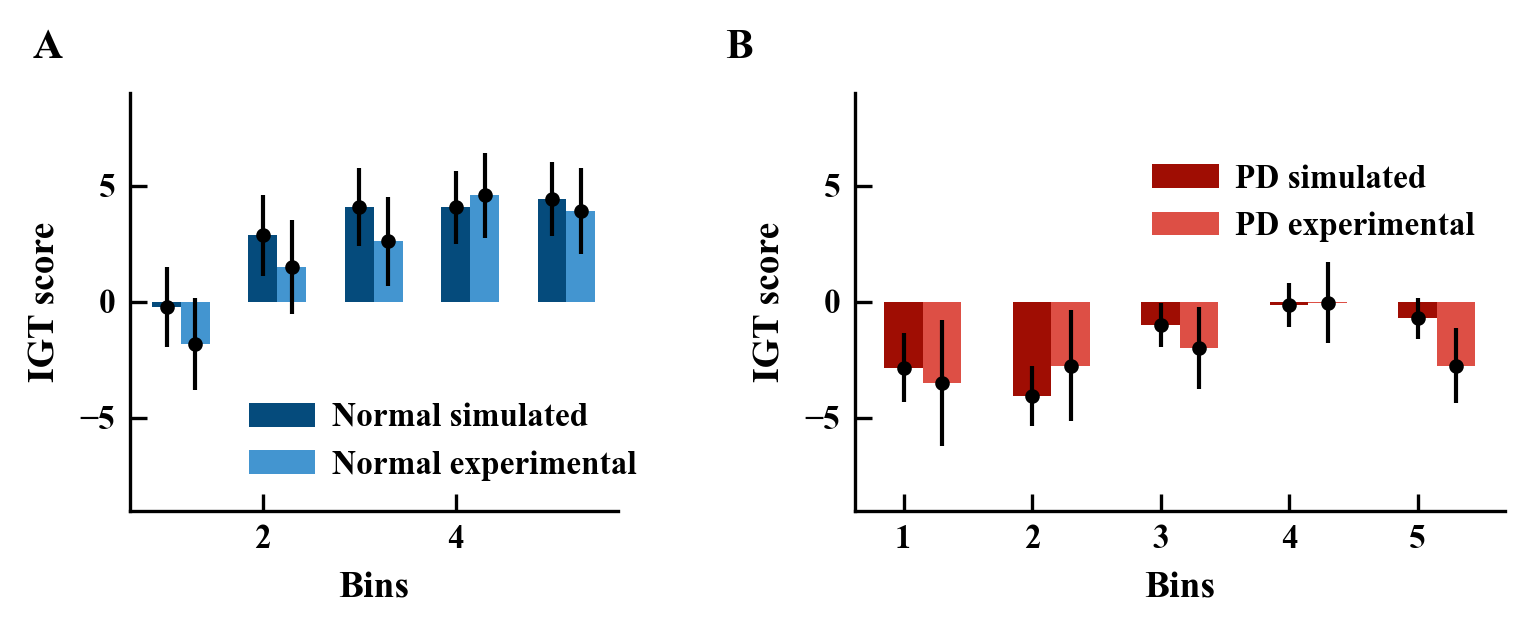

In [5]:
fig = plt.figure(figsize=(5, 2), facecolor='white')
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[0.75,1], height_ratios=[1], hspace=0.1, wspace=0.1)

# Column 1: Top and bottom plots
ax_normal = fig.add_subplot(gs[0, 0])  # Top left
ax_pd = fig.add_subplot(gs[0, 1])  # Bottom left
# Column 2: Centered plot (spanning both rows)
# ax_all = fig.add_subplot(gs[:, 1])   # Right, center (spans both rows)


bin_width = 0.3
ax_normal.bar(np.arange(5)+1, igt_normal, color=colors_sim_expt['normal_sim'], width=0.3, label = 'Normal simulated')
ax_normal.errorbar(np.arange(5)+ 1, igt_normal, yerr=igt_normal_se, color='k', linewidth=1.0, fmt = '.')
ax_normal.bar(np.arange(5)+1+bin_width, igt_normal_expt, color=colors_sim_expt['normal_expt'], width=0.3, label = 'Normal experimental')
ax_normal.errorbar(np.arange(5)+1+bin_width, igt_normal_expt, igt_notmal_expt_se,color = 'k', fmt = '.', linewidth = 1.0)
ax_normal.set_ylim(-9,9)
ax_normal.set_xlabel('Bins')
ax_normal.set_ylabel('IGT score')
ax_normal.legend(ncol = 1, loc = 'lower right', bbox_to_anchor = (1.1, 0.0))

ax_pd.bar(np.arange(5)+1, igt_pd, color=colors_sim_expt['PD_sim'], width=0.3, label= 'PD simulated')
ax_pd.errorbar(np.arange(5)+1, igt_pd, igt_pd_se, color='k', linewidth=1.0, fmt = '.')
ax_pd.bar(np.arange(5)+1 + bin_width, igt_pd_expt, color=colors_sim_expt['PD_expt'], width=0.3, label = 'PD experimental')
ax_pd.errorbar(np.arange(5)+1 + bin_width, igt_pd_expt, igt_pd_expt_se, color='k', linewidth=1.0, fmt = '.')
ax_pd.set_ylim(-9,9)
ax_pd.set_xlabel('Bins')
ax_pd.set_ylabel('IGT score')
ax_pd.legend(ncol = 1, loc = 'upper right', bbox_to_anchor = (1.0, 0.9))

subplot_axes = [ax_normal, ax_pd]
labels = list('AB')
for ax, label in zip(subplot_axes, labels):
    ax.text(-0.2, 1.15, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
# 
# Add a single legend for all conditions at the bottom of the figure
# handles = [
    # Line2D([0], [0], color=colors['normal'], linestyle='-', label='Normal'),
    # Line2D([0], [0], color=colors['PD'], linestyle='-', label='PD'),        
# ]
# fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.175), frameon=False, fontsize=9)

Text(2.5, 14.440000534057617, 'Normal')

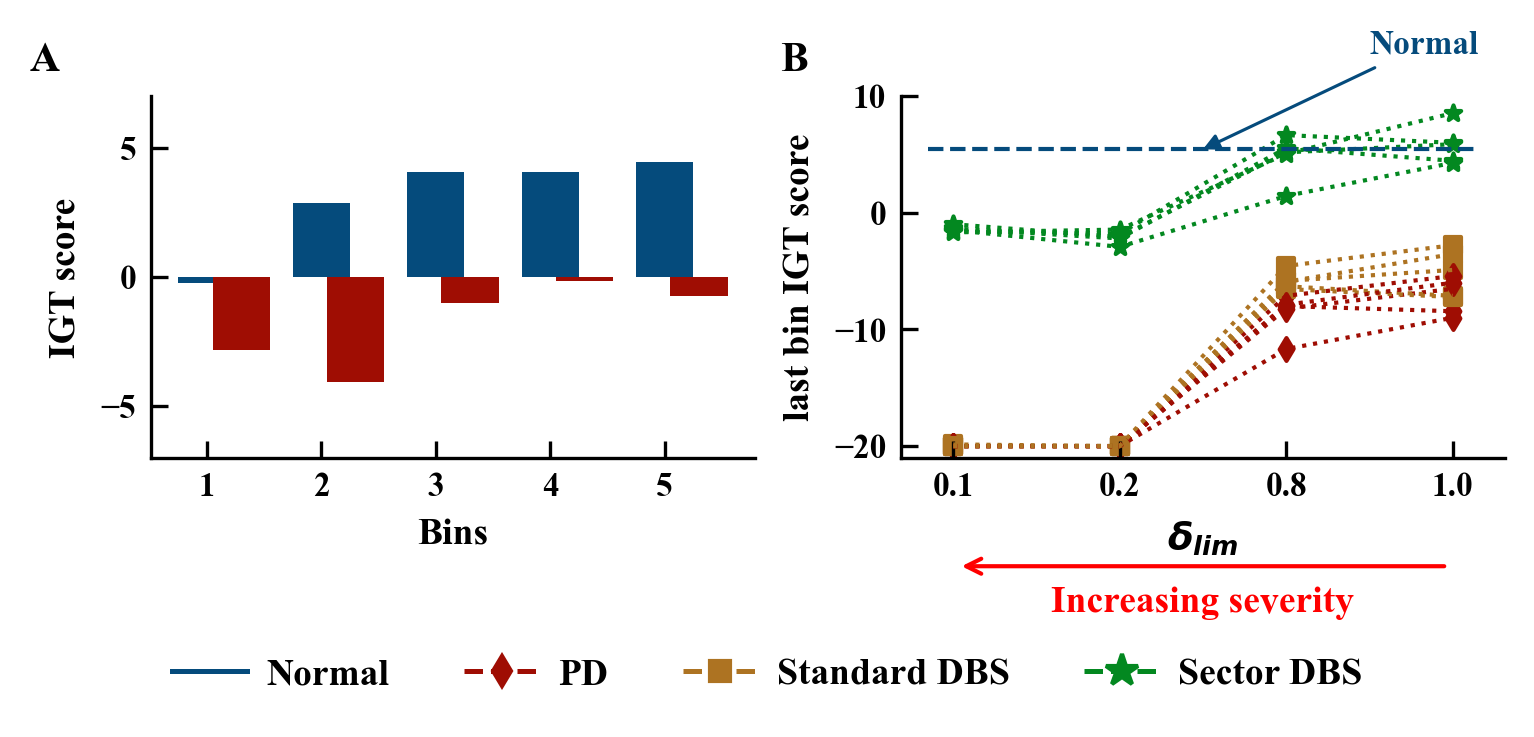

In [6]:
fig = plt.figure(figsize=(5, 2), facecolor='white')
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1,1], height_ratios=[1], hspace=0.1)
ax_normal_pd = fig.add_subplot(gs[0, 0])
ax_all = fig.add_subplot(gs[0, 1])

bin_width = 0.3
ax_normal_pd.bar(np.arange(5)+1, igt_normal, color=colors['normal'], width=0.5)
ax_normal_pd.bar(np.arange(5)+1 + bin_width, igt_pd, color=colors['PD'], width=0.5)
ax_normal_pd.set_ylim(-7,7)
ax_normal_pd.set_xlabel('Bins')
ax_normal_pd.set_ylabel('IGT score')


for i in range(5):
    ax_all.scatter(np.arange(4), last_bin_igt_PD_all_v1[i], marker='d', color=colors['PD'], s=15)
    ax_all.scatter(np.arange(4), last_bin_igt_std_DBS_all_v1[i], marker='s', color=colors['std_DBS'], s=15)
    ax_all.scatter(np.arange(4), last_bin_igt_sector_DBS_all_v1[i], marker='*', color=colors['sector_DBS'], s=15)
    ax_all.plot(np.arange(4), last_bin_igt_PD_all_v1[i], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all.plot(np.arange(4), last_bin_igt_std_DBS_all_v1[i], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all.plot(np.arange(4), last_bin_igt_sector_DBS_all_v1[i], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    ax_all.set_xlabel('$\delta_{lim}$')
    ax_all.set_ylabel('last bin IGT score')
    ax_all.set_xticks(np.arange(4), del_lim_arr)
    ax_all.set_ylim(-21,10)



subplot_axes = [ax_normal_pd, ax_all]
labels = list('AB')
for ax, label in zip(subplot_axes, labels):
    ax.text(-0.2, 1.15, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

# Add a single legend for all conditions at the bottom of the figure
handles = [
    Line2D([0], [0], color=colors['normal'], linestyle='-', label='Normal'),
    Line2D([0], [0], color=colors['PD'], marker='d', linestyle='--', label='PD'),
    Line2D([0], [0], color=colors['std_DBS'], marker='s', linestyle='--', label='Standard DBS'),
    Line2D([0], [0], color=colors['sector_DBS'], marker='*', linestyle='--', label='Sector DBS', markersize = 8),
]
fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.175), frameon=False, fontsize=9)

x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.3
ax_all.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


x_min, x_max = ax_all.get_xlim()
ax_all.hlines(igt_normal[-1]+1, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = igt_normal[-1]+1
y_text = igt_normal[-1]+10

ax_all.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 1, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

## Final Plots

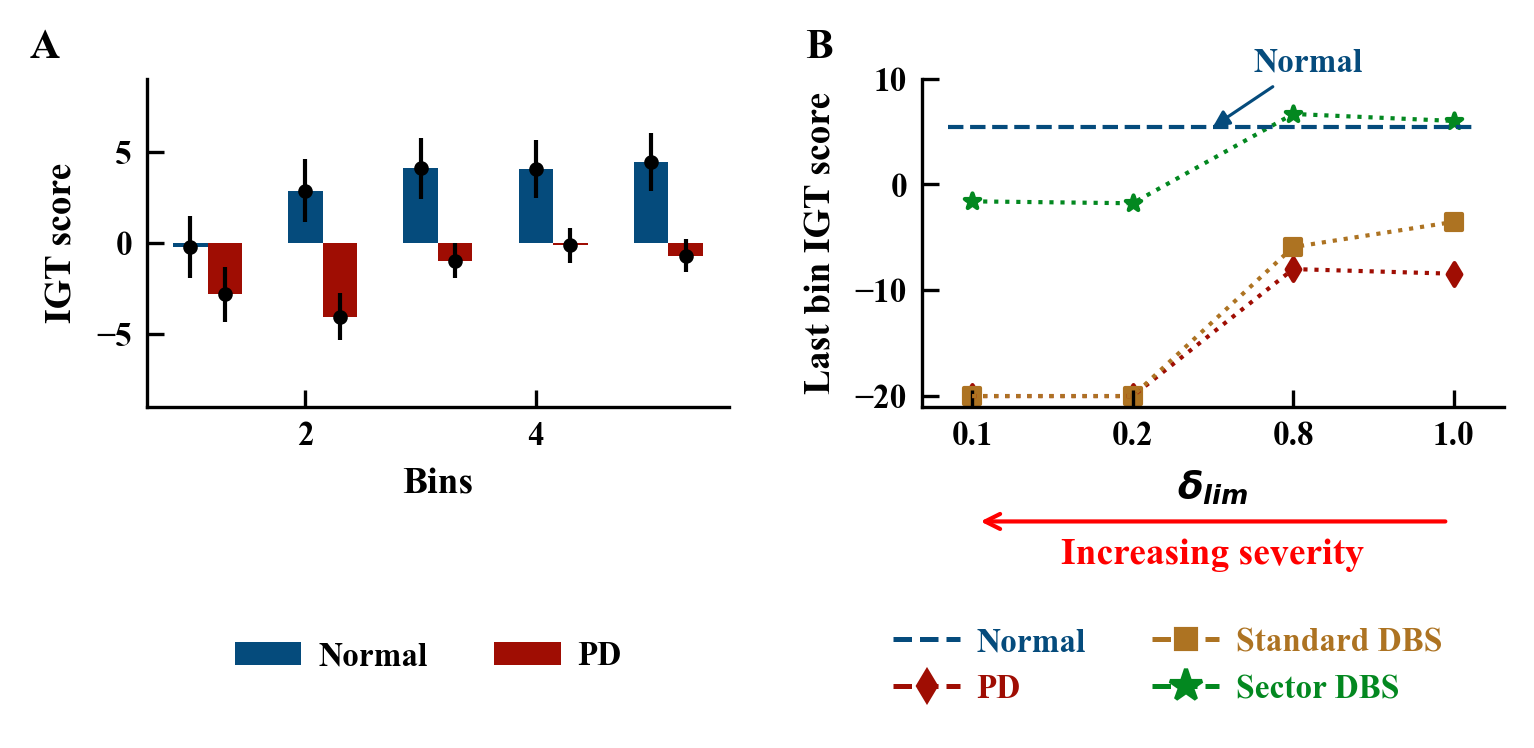

In [7]:
# Add this as a new cell after the existing plots

fig = plt.figure(figsize=(5, 1.6), facecolor='white')
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1,1], height_ratios=[1], hspace=0.1, wspace=0.1)

# Left: Normal and PD IGT scores (same as before)
ax_normal_pd = fig.add_subplot(gs[0, 0])
bin_width = 0.3
ax_normal_pd.bar(np.arange(5)+1, igt_normal, color=colors_sim_expt['normal_sim'], width=0.3, label='Normal')
ax_normal_pd.errorbar(np.arange(5)+1, igt_normal, yerr=igt_normal_se, color='k', linewidth=1.0, fmt='.')
ax_normal_pd.bar(np.arange(5)+1 + 1*bin_width, igt_pd, color=colors_sim_expt['PD_sim'], width=0.3, label='PD')
ax_normal_pd.errorbar(np.arange(5)+1 + 1*bin_width, igt_pd, igt_pd_se, color='k', linewidth=1.0, fmt='.')
ax_normal_pd.set_ylim(-9,9)
ax_normal_pd.set_xlabel('Bins')
ax_normal_pd.set_ylabel('IGT score')
ax_normal_pd.legend(ncol=2, loc='lower left', bbox_to_anchor=(0.1, -0.9), fontsize = 8)


lat_index = 2
# delim_index = 3  # Corresponding to 1.0
ax_all = fig.add_subplot(gs[0, 1])

# Extract data for the single delim across lat_arr
pd_single = last_bin_igt_PD_all_v1[lat_index] #[last_bin_igt_PD_all_v1[i][delim_index] for i in range(len(lat_arr))]
std_dbs_single = last_bin_igt_std_DBS_all_v1[lat_index] #[last_bin_igt_std_DBS_all_v1[i][delim_index] for i in range(len(lat_arr))]
sector_dbs_single = last_bin_igt_sector_DBS_all_v1[lat_index] #[last_bin_igt_sector_DBS_all_v1[i][delim_index] for i in range(len(lat_arr))]

ax_all.scatter(np.arange(len(del_lim_arr)), pd_single, marker='d', color=colors['PD'], s=15, label='PD')
ax_all.scatter(np.arange(len(del_lim_arr)), std_dbs_single, marker='s', color=colors['std_DBS'], s=15, label='Standard DBS')
ax_all.scatter(np.arange(len(del_lim_arr)), sector_dbs_single, marker='*', color=colors['sector_DBS'], s=15, label='Sector DBS')
ax_all.plot(np.arange(len(del_lim_arr)), pd_single, color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
ax_all.plot(np.arange(len(del_lim_arr)), std_dbs_single, color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
ax_all.plot(np.arange(len(del_lim_arr)), sector_dbs_single, color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
ax_all.set_ylabel('Last bin IGT score')
ax_all.set_xlabel('$\delta_{lim}$')
ax_all.set_xticks(np.arange(len(del_lim_arr)), [f'{del_lim:.1f}' for del_lim in del_lim_arr])
ax_all.set_ylim(-21,10)

# Add subplot labels
subplot_axes = [ax_normal_pd, ax_all]
labels = list('AB')
for ax, label in zip(subplot_axes, labels):
    ax.text(-0.2, 1.15, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

# Horizontal line for normal
x_min, x_max = ax_all.get_xlim()
ax_all.hlines(igt_normal[-1]+1, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)
y_ann = igt_normal[-1]+1
y_text = igt_normal[-1]+7
ax_all.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.25, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)

# Add a single legend for all conditions at the bottom of the figure
handles = [
    Line2D([0], [0], color=colors['normal'], linestyle='--', label='Normal'),
    Line2D([0], [0], color=colors['PD'], marker='d', linestyle='--', label='PD'),
    Line2D([0], [0], color=colors['std_DBS'], marker='s', linestyle='--', label='Standard DBS'),
    Line2D([0], [0], color=colors['sector_DBS'], marker='*', linestyle='--', label='Sector DBS', markersize = 8),
]

legend = ax_all.legend(handles=handles, loc='lower left', ncol=2, bbox_to_anchor=(-0.1, -1), frameon=False, fontsize=8)
# legend = ax_all.legend(handles, labels, loc='center left', frameon=False, fontsize=9, bbox_to_anchor=(-0.2, 0.5))
for txt, col in zip(legend.get_texts(), [colors['normal'],colors['PD'], colors['std_DBS'], colors['sector_DBS']]):
    txt.set_color(col)

x_values = del_lim_arr #np.arange(len(del_lim_arr))
x_start = 3 #x_values[-1] 
x_end = 0#x_values[0] 
y_pos = -0.35
ax_all.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
ax_all.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)
# 
# plt.savefig('plots/main_plot_IGT.png', bbox_inches='tight')
# plt.savefig('plots/main_plot_IGT.pdf', bbox_inches='tight')
# plt.savefig('plots/main_plot_IGT.svg', bbox_inches='tight')
plt.show()

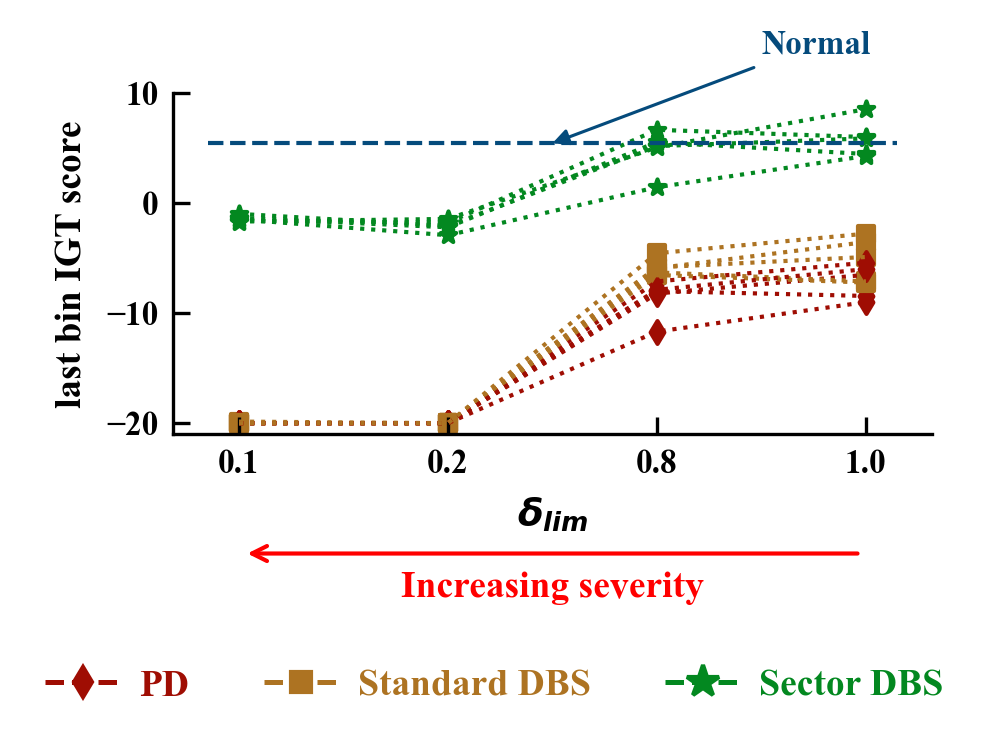

In [8]:
fig = plt.figure(figsize=(3, 2), facecolor='white')

for i in range(5):
    plt.scatter(np.arange(4), last_bin_igt_PD_all_v1[i], marker='d', color=colors['PD'], s=15)
    plt.scatter(np.arange(4), last_bin_igt_std_DBS_all_v1[i], marker='s', color=colors['std_DBS'], s=15)
    plt.scatter(np.arange(4), last_bin_igt_sector_DBS_all_v1[i], marker='*', color=colors['sector_DBS'], s=15)
    plt.plot(np.arange(4), last_bin_igt_PD_all_v1[i], color=colors['PD'], linewidth=1, alpha=1, linestyle='dotted')
    plt.plot(np.arange(4), last_bin_igt_std_DBS_all_v1[i], color=colors['std_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    plt.plot(np.arange(4), last_bin_igt_sector_DBS_all_v1[i], color=colors['sector_DBS'], linewidth=1, alpha=1, linestyle='dotted')
    plt.xlabel('$\delta_{lim}$')
    plt.ylabel('last bin IGT score')
    plt.xticks(np.arange(4), del_lim_arr)
    plt.ylim(-21,10)



# Add a single legend for all conditions at the bottom of the figure
handles = [
    Line2D([0], [0], color=colors['PD'], marker='d', linestyle='--', label='PD'),
    Line2D([0], [0], color=colors['std_DBS'], marker='s', linestyle='--', label='Standard DBS'),
    Line2D([0], [0], color=colors['sector_DBS'], marker='*', linestyle='--', label='Sector DBS', markersize = 8),
]
legend = fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.2), frameon=False, fontsize=9)
for txt, col in zip(legend.get_texts(), [colors['PD'], colors['std_DBS'], colors['sector_DBS']]):
    txt.set_color(col)
x_values = np.arange(len(del_lim_arr))
x_start = x_values[-1] 
x_end = x_values[0] 
y_pos = -0.35
plt.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)
# 
# 4. Add the text at the center of the arrow.
plt.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


x_min, x_max = plt.xlim()
plt.hlines(igt_normal[-1]+1, x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = igt_normal[-1]+1
y_text = igt_normal[-1]+10

plt.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 1, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.75, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)


# plt.text(-1.5, 1.475, 'A', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')


# plt.savefig('plots/supplementary_plot_IGT.png', bbox_inches='tight')
# plt.savefig('plots/supplementary_plot_IGT.pdf', bbox_inches='tight')
# plt.savefig('plots/supplementary_plot_IGT.svg', bbox_inches='tight')